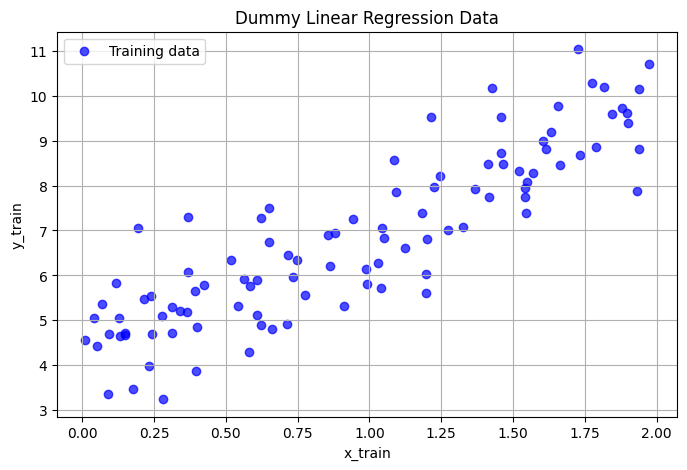

Features shape is: (100, 1)
Target shape is: (100, 1)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set the seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 100

# Generate random x values (features)
x_train = 2 * np.random.rand(num_samples, 1)

# Generate corresponding y values with a linear relationship (y = 4 + 3x + noise)
true_slope = 3
true_intercept = 4
noise = np.random.randn(num_samples, 1)

y_train = true_intercept + true_slope * x_train + noise

# Plotting the data
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="blue", label="Training data", alpha=0.7)
plt.title("Dummy Linear Regression Data")
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape is:",x_train.shape)
print("Target shape is:",y_train.shape)

Epoch 0, Loss: 582.0004
Epoch 100, Loss: 14.2249
Epoch 200, Loss: 14.2250
Epoch 300, Loss: 14.2689
Epoch 400, Loss: 14.1962
Epoch 500, Loss: 14.2248
Epoch 600, Loss: 14.2249
Epoch 700, Loss: 14.2251
Epoch 800, Loss: 14.2698
Epoch 900, Loss: 14.2248
Final Accuracy: 0.0 %


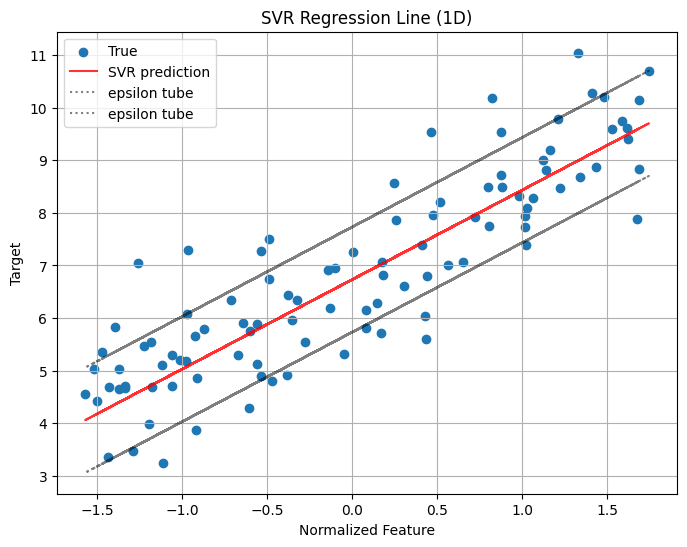

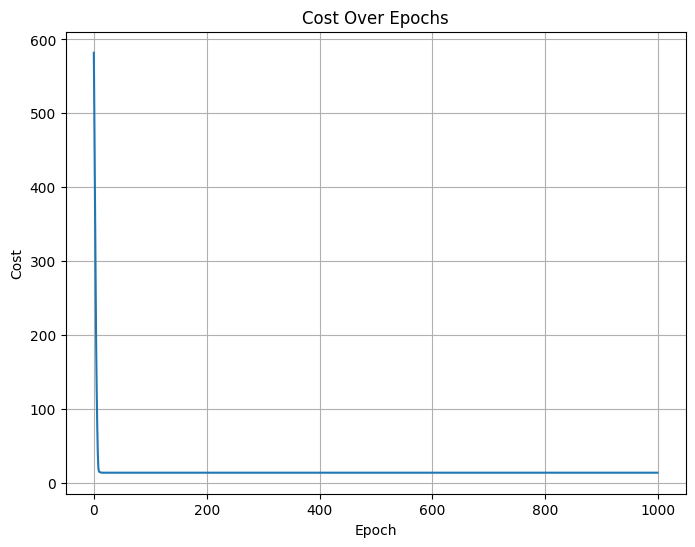

In [ ]:
m, n = x_train.shape
x_norm = (x_train - np.mean(x_train, axis=0)) / np.std(x_train, axis=0)
y = y_train.reshape(-1, 1)
W = np.zeros((n, 1))
b = 0.0
C = 1.0
lr = 0.01
epochs = 1000
epsilon = 1.0
costs = []

for epoch in range(epochs):
    y_predict = x_norm @ W + b
    error = y - y_predict

    indicator_pos = (error > epsilon).astype(float)
    indicator_neg = (error < -epsilon).astype(float)

    dw = W - C * (x_norm.T @ indicator_pos) + C * (x_norm.T @ indicator_neg)
    db = -C * np.sum(indicator_pos) + C * np.sum(indicator_neg)

    W -= lr * dw
    b -= lr * db

    loss = 0.5 * np.sum(W ** 2) + C * np.sum(np.maximum(0, np.abs(error) - epsilon))
    costs.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

y_pred = x_norm @ W + b
plt.figure(figsize=(8, 6))
plt.scatter(x_norm, y, label="True")
plt.plot(x_norm, y_pred, color='r', label="SVR prediction", alpha=0.8)
plt.plot(x_norm, y_pred + epsilon, 'k:', label="epsilon tube", alpha=0.5)
plt.plot(x_norm, y_pred - epsilon, 'k:', label="epsilon tube", alpha=0.5)
plt.title("SVR Regression Line (1D)")
plt.xlabel("Normalized Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(costs)
plt.title("Cost Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()
